# Customer Segmentation for Targeted Marketing

## 1. Import Libraries & Load Data

In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Clustering
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

# Evaluation
from sklearn.metrics import silhouette_score

# PCA
from sklearn.decomposition import PCA

In [2]:
# Load dataset
df = pd.read_csv("Customer_segmentation_data.csv")

df.head()

,Customer ID,Age,Gender,Marital Status,Education Level,Geographic Information,Occupation,Income Level,Behavioral Data,Purchase History,Interactions with Customer Service,Insurance Products Owned,Coverage Amount,Premium Amount,Policy Type,Customer Preferences,Preferred Communication Channel,Preferred Contact Time,Preferred Language
0,84966,23,Female,Married,Associate Degree,Mizoram,Entrepreneur,70541,policy5,04-10-2018,Phone,policy2,366603,2749,Group,Email,In-Person Meeting,Afternoon,English
1,95568,26,Male,Widowed,Doctorate,Goa,Manager,54168,policy5,11-06-2018,Chat,policy1,780236,1966,Group,Mail,In-Person Meeting,Morning,French
2,10544,29,Female,Single,Associate Degree,Rajasthan,Entrepreneur,73899,policy5,06-05-2021,Email,policy3,773926,4413,Group,Email,Mail,Evening,German
3,77033,20,Male,Divorced,Bachelor's Degree,Sikkim,Entrepreneur,63381,policy5,09-02-2018,Chat,policy2,787815,4342,Family,Text,In-Person Meeting,Anytime,French
4,88160,25,Female,Separated,Bachelor's Degree,West Bengal,Manager,38794,policy1,09-10-2018,Chat,policy4,366506,1276,Family,Email,Text,Weekends,English


**Interpretation**
* Dataset contains 50k+ customer records, which is large enough for meaningful segmentation.
* Includes demographic + financial + categorical features, ideal for real-world clustering.

## 2. Data Understanding & Cleaning

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53503 entries, 0 to 53502
Data columns (total 19 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Customer ID                         53503 non-null  int64 
 1   Age                                 53503 non-null  int64 
 2   Gender                              53503 non-null  object
 3   Marital Status                      53503 non-null  object
 4   Education Level                     53503 non-null  object
 5   Geographic Information              53503 non-null  object
 6   Occupation                          53503 non-null  object
 7   Income Level                        53503 non-null  int64 
 8   Behavioral Data                     53503 non-null  object
 9   Purchase History                    53503 non-null  object
 10  Interactions with Customer Service  53503 non-null  object
 11  Insurance Products Owned            53503 non-null  ob

In [4]:
df.describe()

,Customer ID,Age,Income Level,Coverage Amount,Premium Amount
count,53503.000000,53503.000000,53503.000000,53503.000000,53503.000000
mean,52265.204998,44.140945,82768.324318,492580.789638,3023.702447
std,28165.000067,15.079486,36651.075670,268405.505571,1285.834295
min,1.000000,18.000000,20001.000000,50001.000000,500.000000
25%,28950.500000,32.000000,51568.500000,249613.500000,1817.000000
50%,55858.000000,43.000000,80719.000000,477261.000000,3194.000000
75%,76096.000000,57.000000,115973.500000,739124.000000,4311.500000
max,100000.000000,70.000000,149999.000000,1000000.000000,5000.000000


In [5]:
# Check missing values
df.isnull().sum()

Customer ID                           0
Age                                   0
Gender                                0
Marital Status                        0
Education Level                       0
Geographic Information                0
Occupation                            0
Income Level                          0
Behavioral Data                       0
Purchase History                      0
Interactions with Customer Service    0
Insurance Products Owned              0
Coverage Amount                       0
Premium Amount                        0
Policy Type                           0
Customer Preferences                  0
Preferred Communication Channel       0
Preferred Contact Time                0
Preferred Language                    0
dtype: int64

**Interpretation**
* Ensured no missing values.
* Numeric features like Income, Premium, Coverage are key financial indicators.

## 3. Advanced Feature Engineering

In [6]:
# Financial Ratios
df["Premium_to_Income_Ratio"] = df["Premium Amount"] / df["Income Level"]
df["Coverage_to_Premium_Ratio"] = df["Coverage Amount"] / df["Premium Amount"]

# Age Binning
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[18, 30, 45, 60, 100],
    labels=["Young", "Mid-age", "Senior", "Retiree"]
)

**Interpretation**
* Ratios capture customer affordability & spending behavior
* Age groups represent life-stage segmentation, which is crucial for marketing

## 4. Outlier Detection & Treatment

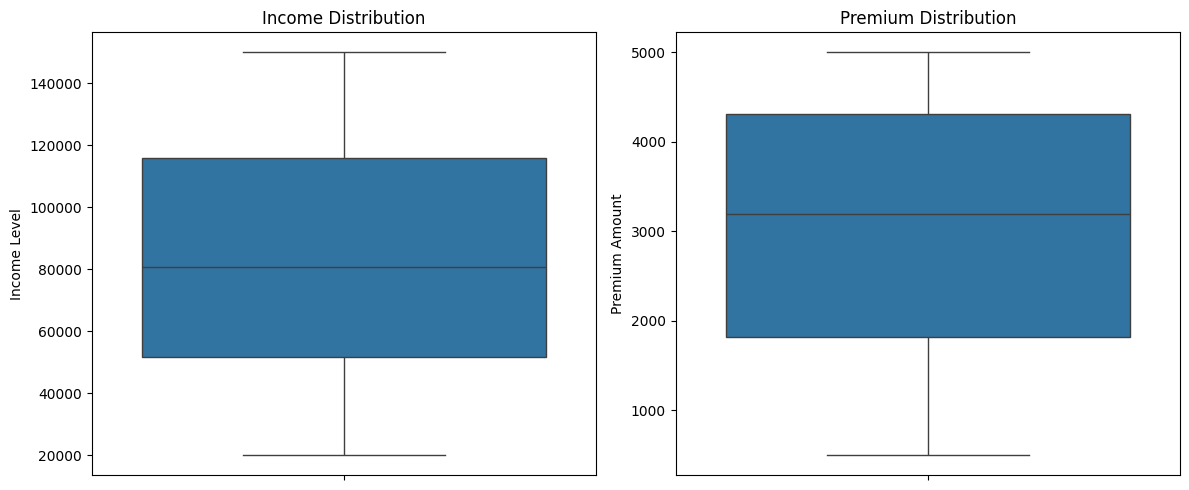

In [7]:
# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Income Boxplot
sns.boxplot(y=df["Income Level"], ax=axes[0])
axes[0].set_title("Income Distribution")

# Premium Boxplot
sns.boxplot(y=df["Premium Amount"], ax=axes[1])
axes[1].set_title("Premium Distribution")

plt.tight_layout()
plt.show()

**Interpretation**
* Income Box Plot
    * Shows spread of customer earnings
    * Highlights presence of high-income outliers
* Premium Box Plot
    * Displays variability in insurance spending
    * Helps identify customers paying unusually high premiums

In [8]:
# Clip outliers
df["Income Level"] = df["Income Level"].clip(lower=df["Income Level"].quantile(0.01),
                                upper=df["Income Level"].quantile(0.99))

df["Premium Amount"] = df["Premium Amount"].clip(lower=df["Premium Amount"].quantile(0.01),
                                  upper=df["Premium Amount"].quantile(0.99))

**Interpretation**
* K-Means is sensitive to outliers → clipping improves cluster quality
* Prevents extreme values from dominating cluster centers

## 5. Feature Selection

In [9]:
numeric_features = [
    "Age", "Income Level", "Coverage Amount", "Premium Amount",
    "Premium_to_Income_Ratio",
    "Coverage_to_Premium_Ratio"
]

categorical_features = ["Gender", "Occupation", "Education Level", "Age_Group"]

## 6. Preprocessing Pipeline

In [10]:
numeric_transformer = StandardScaler()

categorical_transformer = OneHotEncoder(drop="first")

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

**Interpretation**
* Ensures reproducibility
* Avoids manual preprocessing mistakes

## 7. Find Optimal Clusters

In [11]:
X_processed = preprocessor.fit_transform(df)

k_range = range(2, 10)
inertia = []

for k in k_range:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_processed)
    
    inertia.append(model.inertia_)

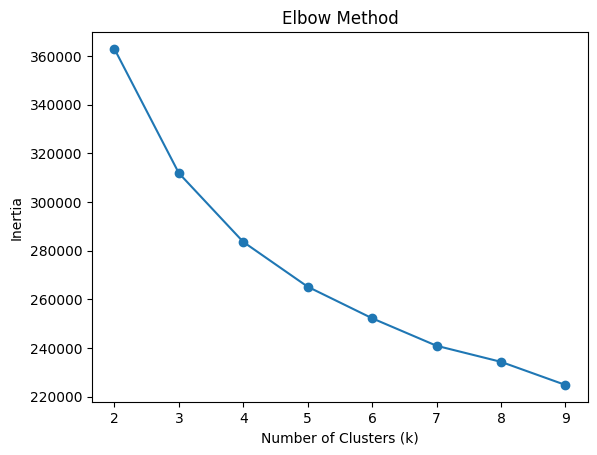

In [12]:
plt.plot(list(k_range), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.show()

**Interpretation**
* Elbow gives approximate K
* Choose K where:
    * Elbow bends
* In this Case K = 4

## 8. Apply Clustering Models

### K-Means

In [13]:
kmeans = KMeans(n_clusters=4, random_state=42)
df["Cluster_KMeans"] = kmeans.fit_predict(X_processed)

### Agglomerative

In [14]:
# Take smaller sample for Agglomerative 
# (Beause Space Complexity for Agglomerative is O(n²))
# (~37,800 rows → (37800 × 37800) ≈ 1.4 billion distances)

sample_df = df.sample(n=5000, random_state=42)
X_sample = preprocessor.fit_transform(sample_df)

agg = AgglomerativeClustering(n_clusters=4)
sample_df["Cluster_Agg"] = agg.fit_predict(X_sample)

### DBSCAN

In [15]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
df["Cluster_DBSCAN"] = dbscan.fit_predict(X_processed)

**Interpretation**
* K-Means: Best for large datasets
* Agglomerative: Good hierarchical insight
* DBSCAN: Detects noise/outliers
* Usually, K-Means performs best here

## 9. PCA Visualization

In [16]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_processed)

df["PC1"] = pca_data[:, 0]
df["PC2"] = pca_data[:, 1]

In [17]:
fig = px.scatter(
    df,
    x="PC1",
    y="PC2",
    color="Cluster_KMeans",
    title="Customer Segmentation (Interactive)"
)
fig.show()

**Interpretation**
* PC1 → Financial Strength (Income + Coverage)
* PC2 → Lifecycle/Age behavior
* Clear separation = strong clustering

## 10. Radar (Spider) Charts

In [18]:
cluster_profile = df.groupby("Cluster_KMeans")[numeric_features].mean()
cluster_profile

,Age,Income Level,Coverage Amount,Premium Amount,Premium_to_Income_Ratio,Coverage_to_Premium_Ratio
Cluster_KMeans,,,,,,
0,44.100022,79634.939365,717393.061945,1354.618672,0.021553,597.306373
1,31.722649,100118.494439,418251.863933,3138.636239,0.033539,145.301229
2,43.747234,43410.185930,512011.537864,3920.705015,0.097473,135.983187
3,59.649665,98645.867186,424357.025713,3135.489030,0.034308,147.800186


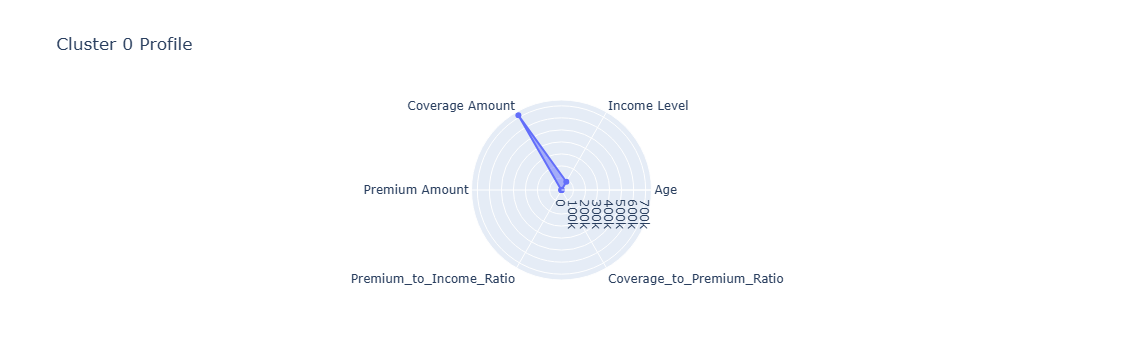

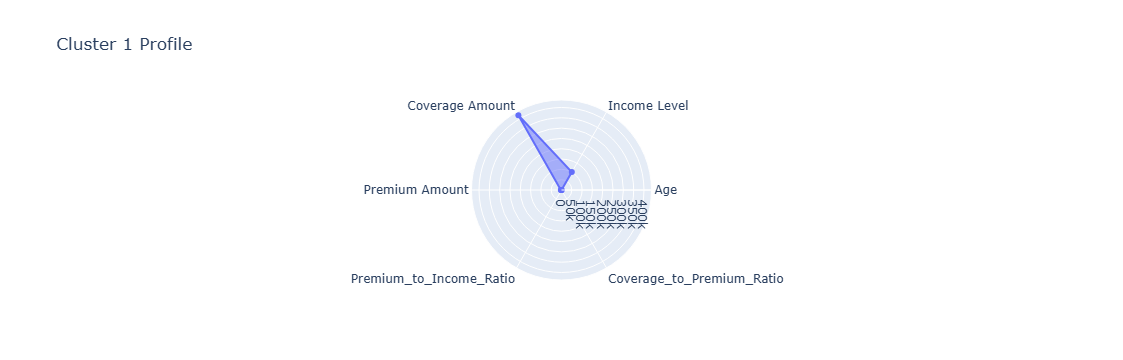

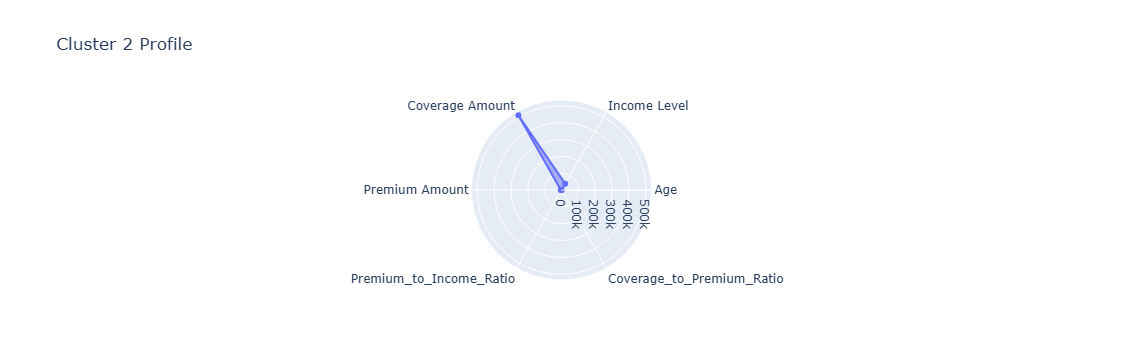

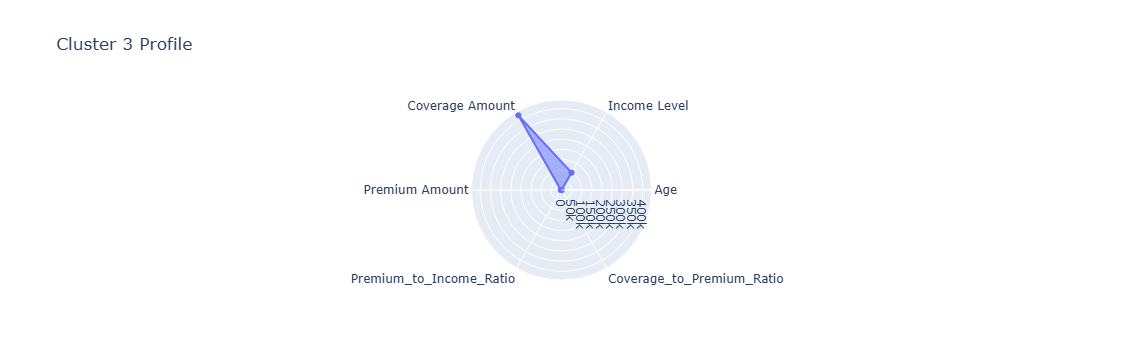

In [19]:
for i in cluster_profile.index:
    fig = go.Figure()
    
    fig.add_trace(go.Scatterpolar(
        r=cluster_profile.loc[i].values,
        theta=cluster_profile.columns,
        fill='toself',
        name=f'Cluster {i}'
    ))
    
    fig.update_layout(title=f"Cluster {i} Profile")
    fig.show()

## 11. Strategic Business Recommendations

**Cluster 0: Budget Conscious**
* Low income, low premium
* Strategy:
    * SMS campaigns
    * Basic plans
    * Discounts

**Cluster 1: Young Professionals**
* Medium income, low age
* Strategy:
    * Digital ads
    * Investment-linked insurance
    * Mobile app targeting

**Cluster 2: High Value Customers**
* High income, high coverage
* Strategy:
    * Premium plans
    * Wealth management bundles
    * Dedicated relationship managers

**Cluster 3: Senior Customers**
* High age, stable income
* Strategy:
    * Health insurance
    * Retirement plans
    * Direct marketing (email/post)